# Housing supply and classifier quality

This study adapts the multiclass queue to a finite-horizon housing-allocation system.

The key differences from a standard queue are:

- homeless people arrive in annual batches
- housing is released in annual batches
- a housing unit is permanently consumed when allocated
- each person must wait one year before becoming eligible for housing
- true chronic status is latent and the policy acts on classified status

The primary outcome is

$$
P(\text{abandon} \mid \text{true chronic}).
$$

The two study parameters are classifier quality and annual housing supply.

In [1]:
from pathlib import Path
import sys

for candidate in (Path.cwd(), Path.cwd().parent):
    if (candidate / "gi_gi_n_gi_multiclass").exists():
        sys.path.insert(0, str(candidate))
        break

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from gi_gi_n_gi_multiclass.core.engine_multi import run_sim_multi
from gi_gi_n_gi_multiclass.core.types_multi import CustomerClass, MultiSimConfig
from gi_gi_n_gi_multiclass.dists.common import Deterministic, Exponential, LogNormal
from gi_gi_n_gi_multiclass.labelling import ConfusionMatrixClassifier
from gi_gi_n_gi_multiclass.metrics.class_metrics import abandonment_probability_by_true_class
from gi_gi_n_gi_multiclass.outputs.schemas import customers_to_dataframe
from gi_gi_n_gi_multiclass.policies.priority_fcfs import PriorityFCFS
from gi_gi_n_gi_multiclass.policies.mtiq import MTIQ

## Housing-mode configuration

Each annual intake contains 200 people:

$$
80 \text{ true chronic}, \qquad 120 \text{ true non-chronic}.
$$

Ten annual cohorts arrive at times

$$
t=0,1,\ldots,9.
$$

Housing is released annually from year 1 onward. A person arriving at time $$t$$ becomes eligible at time

$$
t+1.
$$

Lognormal patience times are used because their hazard rates are non-monotone.

Housing mode also supports ordinary renewal arrivals through each class's interarrival distribution. Batch cadence is set with `batch_interval`: use `1.0` for annual batches or `1.0 / 12.0` for monthly batches.

In [79]:
ANNUAL_CHRONIC = 80
ANNUAL_TRANSIENT = 120
BATCH_COUNTS = [ANNUAL_CHRONIC, ANNUAL_TRANSIENT]

FIRST_BATCH_TIME = 0.0
LAST_BATCH_TIME = 5.0
BATCH_INTERVAL = 1.0

FIRST_HOUSING_RELEASE = 1.0
HOUSING_RELEASE_INTERVAL = 1.0
ELIGIBILITY_DELAY = 1.0

RUN_TIME = 50.0
SEEDS = [1, 2, 3]

# n_servers is interpreted as housing units released per year in housing_mode.
housing_supply_grid = np.arange(60, 140, 4)
classifier_accuracy_grid = np.linspace(0.50, 0.90, 21)

In [80]:
true_chronic = CustomerClass(
    name="chronic",
    interarrival=Deterministic(1.0),   # used only with renewal housing arrivals
    service=Deterministic(0.0),        # housing is allocated instantaneously
    patience=LogNormal(meanlog=1.10, sdlog=0.85),
)

true_transient = CustomerClass(
    name="transient",
    interarrival=Deterministic(1.0),   # used only with renewal housing arrivals
    service=Deterministic(0.0),
    patience=LogNormal(meanlog=0.90, sdlog=0.95),
)

classes = [true_chronic, true_transient]

## Asymmetric classifier path

A single accuracy coordinate is used while false negatives and false positives remain different.

For balanced accuracy $$a$$, define

$$
P(\widehat C=C \mid C=C)=a+0.05
$$

and

$$
P(\widehat C=T \mid C=T)=a-0.05.
$$

The confusion matrix is therefore

$$
\begin{bmatrix}
a+0.05 & 0.95-a \\
1.05-a & a-0.05
\end{bmatrix}.
$$

Within the selected range, chronic sensitivity is always higher than transient specificity, so the two error rates are asymmetric.

In [81]:
def asymmetric_classifier(accuracy: float) -> ConfusionMatrixClassifier:
    sensitivity = accuracy + 0.05
    specificity = accuracy - 0.05

    matrix = np.array([
        [sensitivity, 1.0 - sensitivity],
        [1.0 - specificity, specificity],
    ])
    return ConfusionMatrixClassifier(matrix)

## Arrival-mode sanity checks

These short runs verify the three supported housing-arrival patterns:

- one annual batch of 200 people
- ordinary renewal arrivals with expected annual rates of 80 chronic and 120 non-chronic people
- twelve monthly batches of 8 chronic and 12 non-chronic people

All three retain the same eligibility, abandonment and permanently consumed-housing logic. The monthly example has 240 annual arrivals because integer batch sizes are required.

In [ ]:
renewal_classes = [
    CustomerClass(
        name="chronic",
        interarrival=Exponential(rate=ANNUAL_CHRONIC),
        service=Deterministic(0.0),
        patience=LogNormal(meanlog=1.10, sdlog=0.85),
    ),
    CustomerClass(
        name="transient",
        interarrival=Exponential(rate=ANNUAL_TRANSIENT),
        service=Deterministic(0.0),
        patience=LogNormal(meanlog=0.90, sdlog=0.95),
    ),
]

def arrival_mode_summary(label: str, result) -> dict:
    df = customers_to_dataframe(result)
    times = df["arrival_time"]
    return {
        "arrival_mode": label,
        "arrivals": len(df),
        "distinct_arrival_times": times.nunique(),
        "arrivals_at_t0": int((times == 0.0).sum()),
        "first_arrival": times.min(),
        "last_arrival": times.max(),
        "housed_before_eligibility": int((df["service_start"] < df["eligibility_time"]).sum()),
    }

common_sanity = dict(
    n_servers=100,
    classifier=asymmetric_classifier(0.75),
    policy=PriorityFCFS(priority_order=[0, 1]),
    seed=1,
    warmup_time=0.0,
    run_time=3.0,
    housing_mode=True,
    housing_release_interval=HOUSING_RELEASE_INTERVAL,
    first_housing_release=FIRST_HOUSING_RELEASE,
    initial_housing_stock=0,
    eligibility_delay=ELIGIBILITY_DELAY,
    collect_event_log=True,
)

annual_batch_res = run_sim_multi(MultiSimConfig(
    classes=classes,
    batch_arrival_counts=BATCH_COUNTS,
    batch_interval=1.0,
    first_batch_time=0.0,
    last_batch_time=0.0,
    **common_sanity,
))

renewal_res = run_sim_multi(MultiSimConfig(
    classes=renewal_classes,
    housing_arrival_mode="renewal",
    last_arrival_time=1.0,
    **common_sanity,
))

monthly_batch_res = run_sim_multi(MultiSimConfig(
    classes=classes,
    batch_arrival_counts=[8, 12],
    batch_interval=1.0 / 12.0,
    first_batch_time=0.0,
    last_batch_time=11.0 / 12.0,
    **common_sanity,
))

arrival_mode_diagnostics = pd.DataFrame([
    arrival_mode_summary("annual batch", annual_batch_res),
    arrival_mode_summary("renewal interarrivals", renewal_res),
    arrival_mode_summary("monthly batches", monthly_batch_res),
])
arrival_mode_diagnostics

# Study A: fixed policy

Study A isolates the interaction between classifier quality and housing supply.

The policy is held fixed throughout the full parameter grid:

- assigned chronic first
- FCFS within assigned class **This may be TIQ**

- **If we have an inaccurate classifier, is FCFS better than TIQ generally**

Thus, differences across the diagram are caused only by classifier quality and annual housing supply.

In [83]:
fixed_policy = PriorityFCFS(priority_order=[0, 1])


def run_housing_case(
    classifier_accuracy: float,
    annual_housing_supply: int,
    seed: int,
    policy,
    study: str,
) -> dict:
    cfg = MultiSimConfig(
        n_servers=int(annual_housing_supply),
        classes=classes,
        classifier=asymmetric_classifier(classifier_accuracy),
        policy=policy,
        seed=seed,
        warmup_time=0.0,
        run_time=RUN_TIME,
        housing_mode=True,
        batch_arrival_counts=BATCH_COUNTS,
        batch_interval=BATCH_INTERVAL,
        first_batch_time=FIRST_BATCH_TIME,
        last_batch_time=LAST_BATCH_TIME,
        housing_release_interval=HOUSING_RELEASE_INTERVAL,
        first_housing_release=FIRST_HOUSING_RELEASE,
        initial_housing_stock=0,
        eligibility_delay=ELIGIBILITY_DELAY,
        collect_event_log=False,
    )

    res = run_sim_multi(cfg)
    df = customers_to_dataframe(res)
    chronic = df[df["true_class_id"] == 0]
    transient = df[df["true_class_id"] == 1]

    return {
        "study": study,
        "classifier_accuracy": classifier_accuracy,
        "annual_housing_supply": annual_housing_supply,
        "seed": seed,
        "true_chronic_abandon_prob": abandonment_probability_by_true_class(res, 0),
        "true_transient_abandon_prob": abandonment_probability_by_true_class(res, 1),
        "true_chronic_housed_prob": float((chronic["outcome"] == "SERVED").mean()),
        "true_transient_housed_prob": float((transient["outcome"] == "SERVED").mean()),
        "unresolved_prob": float((df["outcome"] == "IN_SYSTEM_END").mean()),
    }

In [84]:
study_a_rows = []

for annual_housing_supply in housing_supply_grid:
    for classifier_accuracy in classifier_accuracy_grid:
        for seed in SEEDS:
            study_a_rows.append(
                run_housing_case(
                    classifier_accuracy=classifier_accuracy,
                    annual_housing_supply=annual_housing_supply,
                    seed=seed,
                    policy=fixed_policy,
                    study="A_fixed_policy",
                )
            )

study_a_results = pd.DataFrame(study_a_rows)
study_a_summary = (
    study_a_results
    .groupby(["annual_housing_supply", "classifier_accuracy"], as_index=False)
    .mean(numeric_only=True)
)

study_a_summary.head()

,annual_housing_supply,classifier_accuracy,seed,true_chronic_abandon_prob,true_transient_abandon_prob,true_chronic_housed_prob,true_transient_housed_prob,unresolved_prob
0,60,0.50,2.0,0.486806,0.584722,0.513194,0.415278,0.0
1,60,0.52,2.0,0.473611,0.593981,0.526389,0.406019,0.0
2,60,0.54,2.0,0.463889,0.598611,0.536111,0.401389,0.0
3,60,0.56,2.0,0.450694,0.607407,0.549306,0.392593,0.0
4,60,0.58,2.0,0.442361,0.614352,0.557639,0.385648,0.0


## Study A diagram

The colour shows

$$
P(\text{abandon} \mid \text{true chronic}).
$$

Contour lines identify combinations of classifier accuracy and housing supply that produce approximately equal chronic abandonment.

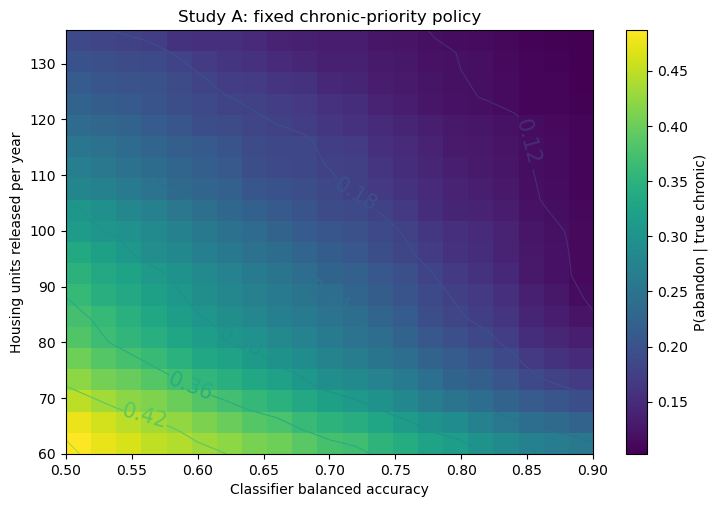

In [85]:
def plot_surface(summary_df: pd.DataFrame, title: str):
    pivot = (
        summary_df
        .pivot(
            index="annual_housing_supply",
            columns="classifier_accuracy",
            values="true_chronic_abandon_prob",
        )
        .sort_index()
    )

    x = pivot.columns.to_numpy(dtype=float)
    y = pivot.index.to_numpy(dtype=float)
    z = pivot.to_numpy(dtype=float)

    fig, ax = plt.subplots(figsize=(8.5, 5.5))
    image = ax.imshow(
        z,
        origin="lower",
        aspect="auto",
        extent=[x.min(), x.max(), y.min(), y.max()],
        interpolation="none",
    )

    contours = ax.contour(x, y, z, levels=6, linewidths=0.8)
    ax.clabel(contours, inline=True, fontsize=15, fmt="%.2f", zorder = 10)

    cbar = fig.colorbar(image, ax=ax)
    cbar.set_label("P(abandon | true chronic)")

    ax.set_xlabel("Classifier balanced accuracy")
    ax.set_ylabel("Housing units released per year")
    ax.set_title(title)
    plt.show()


plot_surface(
    study_a_summary,
    "Study A: fixed chronic-priority policy",
)

## Capacity-information substitutions

The following search identifies examples where a better classifier with less annual housing produces lower chronic abandonment than a worse classifier with more annual housing.

In [86]:
def find_substitution_examples(summary_df: pd.DataFrame, max_examples: int = 10) -> pd.DataFrame:
    rows = []
    records = summary_df.to_dict("records")

    for better in records:
        for worse in records:
            if (
                better["classifier_accuracy"] > worse["classifier_accuracy"]
                and better["annual_housing_supply"] < worse["annual_housing_supply"]
                and better["true_chronic_abandon_prob"] < worse["true_chronic_abandon_prob"]
            ):
                rows.append({
                    "better_accuracy": better["classifier_accuracy"],
                    "lower_supply": better["annual_housing_supply"],
                    "better_outcome": better["true_chronic_abandon_prob"],
                    "worse_accuracy": worse["classifier_accuracy"],
                    "higher_supply": worse["annual_housing_supply"],
                    "worse_outcome": worse["true_chronic_abandon_prob"],
                    "housing_gap": worse["annual_housing_supply"] - better["annual_housing_supply"],
                    "outcome_improvement": (
                        worse["true_chronic_abandon_prob"]
                        - better["true_chronic_abandon_prob"]
                    ),
                })

    if not rows:
        return pd.DataFrame()

    return (
        pd.DataFrame(rows)
        .sort_values(["housing_gap", "outcome_improvement"], ascending=False)
        .head(max_examples)
        .reset_index(drop=True)
    )


study_a_substitutions = find_substitution_examples(study_a_summary)
study_a_substitutions

,better_accuracy,lower_supply,better_outcome,worse_accuracy,higher_supply,worse_outcome,housing_gap,outcome_improvement
0,0.90,72,0.170833,0.50,136,0.186806,64,0.015972
1,0.90,72,0.170833,0.52,136,0.183333,64,0.012500
2,0.90,72,0.170833,0.54,136,0.178472,64,0.007639
3,0.88,72,0.179167,0.50,136,0.186806,64,0.007639
4,0.90,68,0.195139,0.50,132,0.200000,64,0.004861
5,0.88,72,0.179167,0.52,136,0.183333,64,0.004167
6,0.90,72,0.170833,0.56,136,0.172917,64,0.002083
7,0.90,68,0.195139,0.52,132,0.196528,64,0.001389
8,0.90,76,0.150694,0.50,136,0.186806,60,0.036111
9,0.90,76,0.150694,0.52,136,0.183333,60,0.032639


# Study B: classifier-dependent policy

Study B allows the allocation rule to become less extreme when the classifier is less reliable.

For a highly accurate classifier, assigned chronic people receive priority weight 1 and assigned transient people receive priority weight 0.

As classifier accuracy falls, the assigned-transient priority weight becomes nonzero. This protects truly chronic people who have been misclassified into the transient queue.

The policy below is an interpretable policy-adaptation proxy. It should not be described as a mathematically proven optimum without a separate optimization step.

In [87]:
def classifier_dependent_policy(accuracy: float) -> MTIQ:
    # At accuracy 0.90, beta_transient = 0.
    # At accuracy 0.60, beta_transient = 0.50.
    beta_transient = 0.50 * (0.90 - accuracy) / (0.90 - 0.60)
    beta_transient = float(np.clip(beta_transient, 0.0, 0.50))

    return MTIQ(
        beta=[
            lambda n: 1.0 / (1.0 + n),
            lambda n, b=beta_transient: b / (1.0 + n),
        ],
        w_l=None,
        w_h=None,
        name=f"classifier_dependent_beta_{beta_transient:.3f}",
    )

In [88]:
study_b_rows = []

for annual_housing_supply in housing_supply_grid:
    for classifier_accuracy in classifier_accuracy_grid:
        policy = classifier_dependent_policy(classifier_accuracy)
        for seed in SEEDS:
            study_b_rows.append(
                run_housing_case(
                    classifier_accuracy=classifier_accuracy,
                    annual_housing_supply=annual_housing_supply,
                    seed=seed,
                    policy=policy,
                    study="B_classifier_dependent_policy",
                )
            )

study_b_results = pd.DataFrame(study_b_rows)
study_b_summary = (
    study_b_results
    .groupby(["annual_housing_supply", "classifier_accuracy"], as_index=False)
    .mean(numeric_only=True)
)

study_b_summary.head()

,annual_housing_supply,classifier_accuracy,seed,true_chronic_abandon_prob,true_transient_abandon_prob,true_chronic_housed_prob,true_transient_housed_prob,unresolved_prob
0,60,0.50,2.0,0.447917,0.611574,0.552083,0.388426,0.0
1,60,0.52,2.0,0.452083,0.609259,0.547917,0.390741,0.0
2,60,0.54,2.0,0.446528,0.612963,0.553472,0.387037,0.0
3,60,0.56,2.0,0.443056,0.615278,0.556944,0.384722,0.0
4,60,0.58,2.0,0.440278,0.617593,0.559722,0.382407,0.0


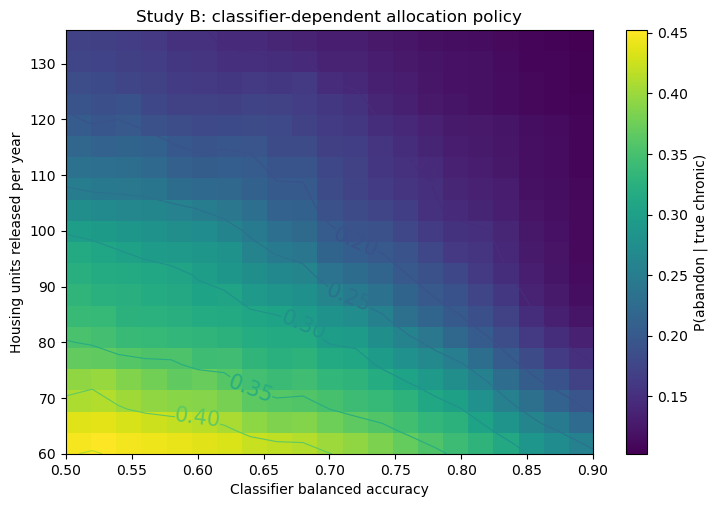

In [89]:
plot_surface(
    study_b_summary,
    "Study B: classifier-dependent allocation policy",
)

## Study A versus Study B

The difference

$$
P_{\mathrm{ab},C}^{B}-P_{\mathrm{ab},C}^{A}
$$

shows whether softening the policy under weaker classification improves or worsens outcomes for truly chronic people.

In [90]:
comparison = study_a_summary.merge(
    study_b_summary,
    on=["annual_housing_supply", "classifier_accuracy"],
    suffixes=("_A", "_B"),
)

comparison["chronic_abandon_difference_B_minus_A"] = (
    comparison["true_chronic_abandon_prob_B"]
    - comparison["true_chronic_abandon_prob_A"]
)

comparison[[
    "annual_housing_supply",
    "classifier_accuracy",
    "true_chronic_abandon_prob_A",
    "true_chronic_abandon_prob_B",
    "chronic_abandon_difference_B_minus_A",
]].head()

,annual_housing_supply,classifier_accuracy,true_chronic_abandon_prob_A,true_chronic_abandon_prob_B,chronic_abandon_difference_B_minus_A
0,60,0.50,0.486806,0.447917,-0.038889
1,60,0.52,0.473611,0.452083,-0.021528
2,60,0.54,0.463889,0.446528,-0.017361
3,60,0.56,0.450694,0.443056,-0.007639
4,60,0.58,0.442361,0.440278,-0.002083


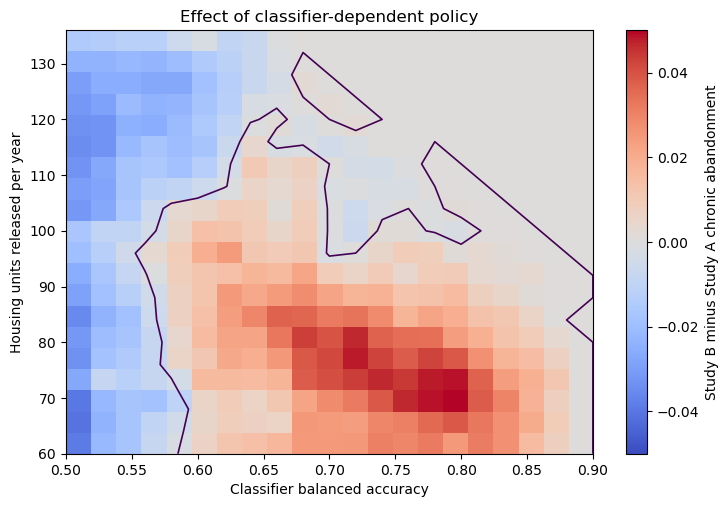

In [91]:
pivot_difference = (
    comparison
    .pivot(
        index="annual_housing_supply",
        columns="classifier_accuracy",
        values="chronic_abandon_difference_B_minus_A",
    )
    .sort_index()
)

x = pivot_difference.columns.to_numpy(dtype=float)
y = pivot_difference.index.to_numpy(dtype=float)
z = pivot_difference.to_numpy(dtype=float)

fig, ax = plt.subplots(figsize=(8.5, 5.5))
scale = np.nanmax(np.abs(z))
image = ax.imshow(
    z,
    origin="lower",
    aspect="auto",
    extent=[x.min(), x.max(), y.min(), y.max()],
    interpolation="none",
    cmap="coolwarm",
    vmin=-scale,
    vmax=scale,
)

ax.contour(x, y, z, levels=[0.0], linewidths=1.2)
cbar = fig.colorbar(image, ax=ax)
cbar.set_label("Study B minus Study A chronic abandonment")

ax.set_xlabel("Classifier balanced accuracy")
ax.set_ylabel("Housing units released per year")
ax.set_title("Effect of classifier-dependent policy")
plt.show()

## Interpretation

Study A gives the clean information-capacity comparison because the policy is fixed.

Study B asks whether policy adaptation can partially protect chronic people who are misclassified when the classifier is weaker.

The central empirical comparison is whether there are parameter pairs satisfying

$$
P_{\mathrm{ab},C}(a_{\mathrm{high}},H_{\mathrm{low}})
<
P_{\mathrm{ab},C}(a_{\mathrm{low}},H_{\mathrm{high}}).
$$

Such a result does not imply that classification replaces housing supply generally. It demonstrates that, under the modeled intake, patience, eligibility and allocation assumptions, better targeting can outweigh a specified increase in annual housing stock for the chronic-abandonment objective.